In [1]:
!pip install mysql-connector-python

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import mysql.connector

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
connection=mysql.connector.connect(
host='localhost',
user= 'root',
password='12345',
database='Project'
) 
#connect mysql to Jupter Notebook

In [8]:
query= 'select * from ecommerce_sales_dataset'
query

'select * from ecommerce_sales_dataset'

In [9]:
df=pd.read_sql(query,connection)
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_2064\2495598824.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,connection)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,4/13/2022,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,3/12/2023,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,9/28/2022,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,4/17/2022,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,3/13/2022,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,9/3/2022,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,7/3/2022,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2/17/2023,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,9/30/2022,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [10]:
import numpy as np

# 3% missing values in product_category
df.loc[df.sample(frac=0.05).index, 'product_category'] = np.nan

# 0.5% missing values in rating
df.loc[df.sample(frac=0.003).index, 'rating'] = np.nan

In [11]:
df.shape

(50000, 13)

In [12]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

# Checking the dtypes of each cloumns

In [13]:
df.dtypes

order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object

In [14]:
#order date having data types object so changing into date time.
df['order_date'] = pd.to_datetime(df['order_date'])

In [15]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,NaN,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  47500 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            49850 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(3)
memory usage: 5.0+ MB


In [17]:
df.describe()

,order_id,order_date,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,49850.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2022-12-31 10:47:16.800000256,2986.848740,252.507260,13.340700,2.999400,2.996299,249.329280,218.886566,657.331475
min,1.000000,2022-01-01 00:00:00,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,2022-07-02 00:00:00,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2023-01-02 00:00:00,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,2023-07-02 00:00:00,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,2023-12-31 00:00:00,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000
std,14433.901067,NaN,1156.374535,143.025544,9.850694,1.415401,1.154476,144.251981,127.317681,526.223968


In [18]:
df.describe(include =object)# view the describe the object values using(include =object)

,product_category,customer_region,payment_method
count,47500,50000,50000
unique,6,4,5
top,Beauty,Asia,Wallet
freq,8033,12526,10106


# Missing Value Detection

In [19]:
#missing values check
df.isna().sum()

order_id               0
order_date             0
product_id             0
product_category    2500
price                  0
discount_percent       0
quantity_sold          0
customer_region        0
payment_method         0
rating               150
review_count           0
discounted_price       0
total_revenue          0
dtype: int64

In [20]:
# there is missing value in Rating and product_category cloumns

# Missing Value imputation

In [21]:
df.dropna(subset = ['rating'], inplace=True) #3% percent values is missing in rating columns

In [22]:
df.shape

(49850, 13)

In [23]:
df.isna().sum()

order_id               0
order_date             0
product_id             0
product_category    2497
price                  0
discount_percent       0
quantity_sold          0
customer_region        0
payment_method         0
rating                 0
review_count           0
discounted_price       0
total_revenue          0
dtype: int64

In [24]:
df['product_category'].mode()

0    Beauty
Name: product_category, dtype: object

In [25]:
df['product_category'] = df['product_category'].fillna('Beauty')

In [26]:
df.isna().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [27]:
df.shape

(49850, 13)

# Duplicated Rows

In [28]:
df.duplicated().sum()#This is find number of duplicates in data

0

In [29]:
df.drop_duplicates(inplace=True) #Deleting all duplicates from data.

In [30]:
df.shape

(49850, 13)

# Featuers Engineering

In [31]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [32]:
df['year'] = df['order_date'].dt.year

In [33]:
df['month']=df['order_date'].dt.month_name()

In [34]:
df['day'] = df['order_date'].dt.day

In [35]:
df['day_name'] = df['order_date'].dt.day_name()

In [36]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day,day_name
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,April,13,Wednesday
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,March,12,Sunday
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,September,28,Wednesday
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,April,17,Sunday
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,March,13,Sunday


In [37]:
df.shape

(49850, 17)

In [38]:
#this is clean data for Data Anaysis
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day,day_name
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,April,13,Wednesday
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,March,12,Sunday
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,September,28,Wednesday
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,April,17,Sunday
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,March,13,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022,September,3,Saturday
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022,July,3,Sunday
49997,49998,2023-02-17,4651,Beauty,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023,February,17,Friday
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022,September,30,Friday


In [39]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'year', 'month', 'day', 'day_name'],
      dtype='object')

In [40]:
df.shape

(49850, 17)

In [41]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day,day_name
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,April,13,Wednesday
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,March,12,Sunday
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,September,28,Wednesday
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,April,17,Sunday
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,March,13,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022,September,3,Saturday
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022,July,3,Sunday
49997,49998,2023-02-17,4651,Beauty,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023,February,17,Friday
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022,September,30,Friday


In [42]:
df['discount_percent'].unique()

array([10, 20, 15,  0, 30,  5], dtype=int64)

In [43]:
def discount(x):
    if x <= 10:
        return 'Low'
    elif x > 10 and x < 20:
        return 'Medium'
    else:
        return 'high'


In [44]:
discount(15)

'Medium'

In [45]:
df['discount_category'] = df['discount_percent'].apply(discount)

In [46]:
df['rating'].unique()

array([3.5, 3.7, 4.4, 5. , 4.6, 3.8, 1.6, 3.4, 2.8, 2. , 4.3, 3.6, 1.4,
       2.7, 2.9, 1.2, 2.4, 1. , 1.1, 4.1, 4.5, 1.9, 1.3, 3.9, 3.1, 2.6,
       4. , 2.1, 4.2, 2.5, 3.3, 2.3, 3.2, 1.7, 2.2, 3. , 4.7, 1.5, 4.8,
       1.8, 4.9])

In [47]:
def rating(x):
    if x <= 2 :
        return 'Low'
    elif x > 2 and x <= 3.6:
        return 'Medium'
    else:
        return 'High'

In [48]:
rating(3.9)

'High'

In [49]:
df['rating_category'] = df['rating'].apply(rating)

In [50]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'year', 'month', 'day', 'day_name',
       'discount_category', 'rating_category'],
      dtype='object')

# EDA

In [51]:
df.shape

(49850, 19)

## Sales Performance Analysis

#### How many total orders are in the sales?

In [52]:
total_orders = df.shape[0]
print(total_orders)

49850


#### What is the total revenue generated from all sales?

In [53]:
total_revenue = df['total_revenue'].sum()
print(total_revenue)

32755374.260000005


#### Identify high revenue but low rating products

In [54]:
result = df.groupby(["product_id","product_category"]).agg({
    "total_revenue": "sum",
    "rating": "min"
}).reset_index()

In [55]:
result = result.sort_values(by="total_revenue", ascending=False).head(10)
# Show top results
print(result.head(10))

       product_id product_category  total_revenue  rating
19794        4781   Home & Kitchen        8640.37     1.7
15154        3892           Beauty        8114.17     2.0
16071        4069          Fashion        8088.71     1.4
11652        3222           Sports        8087.70     1.9
12891        3455          Fashion        7946.00     2.3
16664        4184           Beauty        7932.13     1.9
15631        3984           Beauty        7890.93     1.1
15899        4037   Home & Kitchen        7879.55     2.3
18794        4590          Fashion        7700.83     1.1
6005         2143           Beauty        7516.43     1.0


#### Time-Based Analysis

##### Which month has the highest revenue?

In [56]:
monthly_sales=df.groupby('month')['total_revenue'].sum()
print(monthly_sales.idxmax())
print(monthly_sales.max())

January
2875659.34


##### Which month has the lowest revenue?

In [57]:
print("Lowest Sales Month:", monthly_sales.idxmin())
print("Lowest Sales Amount:", monthly_sales.min())

Lowest Sales Month: February
Lowest Sales Amount: 2500839.99


### Average Sales day 

In [58]:
df.groupby('day_name')['total_revenue'].mean()

day_name
Friday       667.162599
Monday       652.468123
Saturday     661.969022
Sunday       656.811168
Thursday     652.063369
Tuesday      654.467169
Wednesday    654.232743
Name: total_revenue, dtype: float64

### What is the average daily revenue?

In [59]:
day_sales = df.groupby('day_name')['total_revenue'].sum().sort_values(ascending=False)

print(day_sales)

day_name
Friday       4869619.81
Sunday       4732981.28
Saturday     4717191.25
Thursday     4637474.68
Tuesday      4602213.13
Wednesday    4599256.18
Monday       4596637.93
Name: total_revenue, dtype: float64


##### Which day of the week has the lowest sales?

In [60]:
df.groupby('day_name')['total_revenue'].sum().sort_values().head(1)

day_name
Monday    4596637.93
Name: total_revenue, dtype: float64

In [61]:
print("Highest Sales Day:", day_sales.idxmax())
print("Highest Sales Amount:", day_sales.max())

Highest Sales Day: Friday
Highest Sales Amount: 4869619.81


##### top 3 products generate the highest revenue in each year?
##### revenue by year and product

In [62]:
year_product_revenue = df.groupby(['year','product_id','product_category'])['total_revenue'].sum().reset_index()

year_product_revenue


,year,product_id,product_category,total_revenue
0,2022,1000,Beauty,1082.16
1,2022,1000,Books,1245.78
2,2022,1000,Fashion,863.55
3,2022,1000,Home & Kitchen,2618.31
4,2022,1000,Sports,446.37
...,...,...,...,...
30833,2023,4999,Books,1085.25
30834,2023,4999,Electronics,2391.84
30835,2023,4999,Fashion,1479.64
30836,2023,4999,Home & Kitchen,51.08


In [63]:
top5_products_each_year = year_product_revenue.sort_values(['year','total_revenue'], ascending=[True, False]) \
                                              .groupby('year') \
                                              .head(5)

top5_products_each_year

,year,product_id,product_category,total_revenue
10691,2022,3749,Fashion,6736.44
7464,2022,2919,Beauty,6339.89
12335,2022,4184,Beauty,6214.14
11621,2022,3993,Home & Kitchen,6033.54
7994,2022,3049,Beauty,6030.64
15661,2023,1057,Electronics,5846.80
15561,2023,1028,Fashion,5801.40
16227,2023,1210,Electronics,5771.83
21048,2023,2456,Beauty,5743.08
27612,2023,4153,Fashion,5733.15


##### top 3 products each year

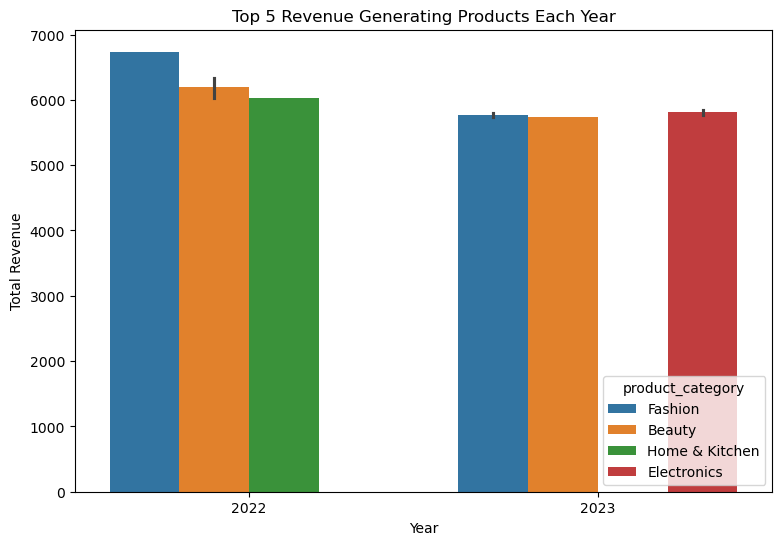

In [64]:
plt.figure(figsize=(9,6))
sns.barplot(data=top5_products_each_year,
            x='year',
            y='total_revenue',
            hue='product_category')

plt.title('Top 5 Revenue Generating Products Each Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.show()

##### Which year and month combination performs best?

In [65]:
df.groupby(['year','month'])['total_revenue'].sum().sort_values(ascending=False).head(5)

year  month  
2023  January    1460393.97
2022  August     1443016.94
2023  July       1436668.16
      May        1422239.45
      October    1420919.15
Name: total_revenue, dtype: float64

## Payment Method Analysis

In [66]:
df['payment_method'].value_counts()

payment_method
Wallet              10071
UPI                 10045
Debit Card           9953
Cash on Delivery     9900
Credit Card          9881
Name: count, dtype: int64

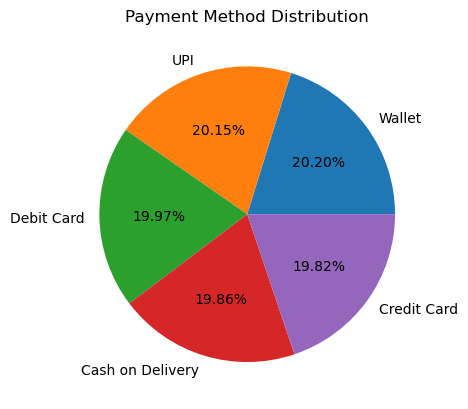

In [67]:
payment_counts = df['payment_method'].value_counts()

plt.figure()
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.2f%%')
plt.title("Payment Method Distribution")
plt.show()

# Product Analysis

##### Which product category generates the highest revenue?

In [68]:
df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

product_category
Beauty            6896550.47
Fashion           5216526.33
Home & Kitchen    5197004.45
Books             5179003.00
Electronics       5153422.11
Sports            5112867.90
Name: total_revenue, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_2064\2007232855.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='product_category', y='total_revenue', data=df,
C:\Users\Admin\AppData\Local\Temp\ipykernel_2064\2007232855.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category', y='total_revenue', data=df,


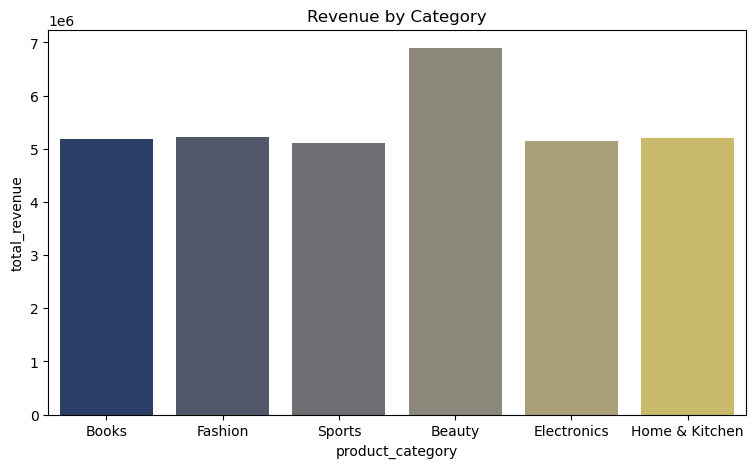

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
sns.barplot(x='product_category', y='total_revenue', data=df,
            estimator=sum, palette="cividis",ci=None)
plt.title("Revenue by Category")
plt.show()


##### The Beauty category generates the highest revenue (~6.9M), while other categories generate around 5.1M–5.2M revenue. This shows that Beauty products are the most profitable category.

##### Which product category has the highest demand?

In [70]:
product_demand = df.groupby('product_category')['quantity_sold'].sum().sort_values(ascending=False)
product_demand

product_category
Beauty            31545
Fashion           23888
Books             23668
Home & Kitchen    23510
Electronics       23455
Sports            23438
Name: quantity_sold, dtype: int64

In [71]:
#What is average revenue per product category
avg_revenue = df.groupby("product_category")["total_revenue"].mean().sort_values(ascending=False)
print(avg_revenue)

product_category
Home & Kitchen    662.123130
Books             658.068996
Electronics       657.240417
Beauty            656.689247
Fashion           655.260185
Sports            653.234688
Name: total_revenue, dtype: float64


# Region Analysis

#### Which region generates the highest revenue?

In [72]:
region_revenue=df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)
region_revenue

customer_region
Middle East      8275454.91
North America    8242753.42
Asia             8158691.82
Europe           8078474.11
Name: total_revenue, dtype: float64

In [73]:
region_revenue.index

Index(['Middle East', 'North America', 'Asia', 'Europe'], dtype='object', name='customer_region')

In [74]:
region_revenue.values

array([8275454.91, 8242753.42, 8158691.82, 8078474.11])

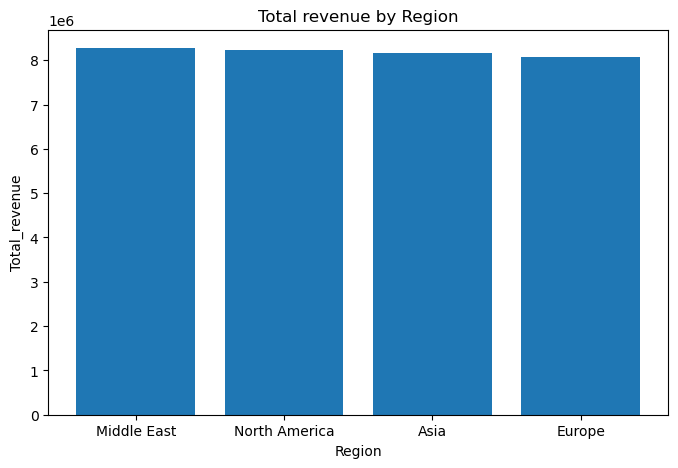

In [75]:
plt.figure(figsize=(8,5))
plt.bar(region_revenue.index,region_revenue.values)
plt.xlabel('Region')
plt.ylabel('Total_revenue')
plt.title('Total revenue by Region')
plt.savefig('demo.png')

#### Middle East = 8,282,727 (Highest Revenue)

In [76]:
#highest average quantity sold by region
region_sales=df.groupby('customer_region')['quantity_sold'].mean().sort_values(ascending=False)
region_sales

customer_region
Middle East      3.012827
North America    2.998877
Europe           2.995567
Asia             2.989040
Name: quantity_sold, dtype: float64

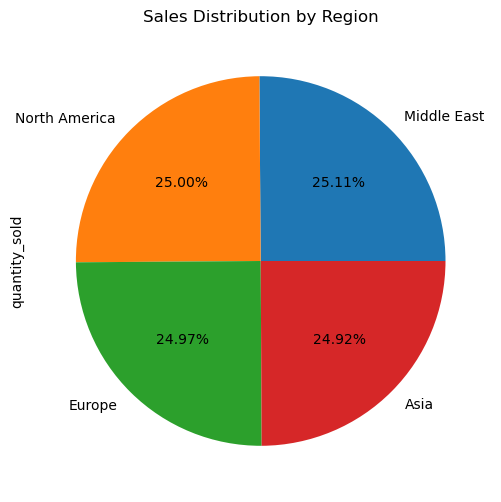

In [77]:
plt.figure(figsize=(6,6))
region_sales.plot(kind='pie', autopct='%1.2f%%')

plt.title('Sales Distribution by Region')
plt.savefig("Sales Distribution by Region.png")

# Discount Analysis

In [78]:
df['discount_percent'].mean()#average discount percentage

13.340020060180542

In [79]:
#  find out the highest discount product
df.loc[df['discount_percent'].idxmax(), ['product_category', 'discount_percent']]

product_category    Sports
discount_percent        30
Name: 5, dtype: object

In [80]:
# highest sales Discount category as per product_category
df.groupby(['discount_category','product_category'])['total_revenue'].sum().sort_values(ascending=False)

discount_category  product_category
Low                Beauty              3805308.69
                   Home & Kitchen      2890348.43
                   Books               2869238.56
                   Electronics         2854200.58
                   Fashion             2846841.14
                   Sports              2749571.39
high               Beauty              1968796.16
                   Books               1533018.68
                   Sports              1520111.18
                   Fashion             1514249.48
                   Home & Kitchen      1451808.39
                   Electronics         1449699.62
Medium             Beauty              1122445.62
                   Fashion              855435.71
                   Home & Kitchen       854847.63
                   Electronics          849521.91
                   Sports               843185.33
                   Books                776745.76
Name: total_revenue, dtype: float64

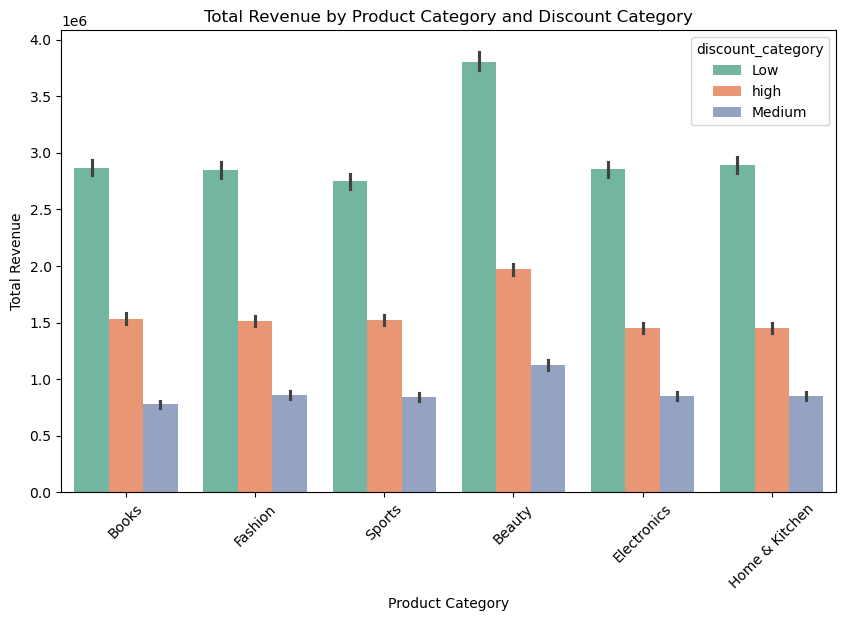

<Figure size 640x480 with 0 Axes>

In [81]:
plt.figure(figsize=(10,6))

sns.barplot(x='product_category',
            y='total_revenue',
            hue='discount_category',
            data=df,
            estimator=sum,
            palette='Set2')

plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Product Category and Discount Category')

plt.xticks(rotation=45)
plt.show()
plt.savefig("Total Revenue by Product Category and Discount Category.png")

In [82]:
#Which discount category (Low, Medium, High) has the highest sales?
discount_sales = df.groupby('discount_category')['total_revenue'].sum().sort_values(ascending=False)
print(discount_sales)


discount_category
Low       18015508.79
high       9437683.51
Medium     5302181.96
Name: total_revenue, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_2064\3652904140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_sales.index,


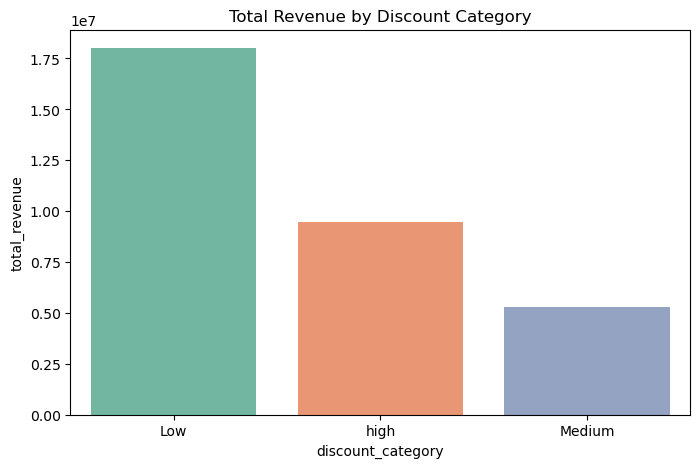

<Figure size 640x480 with 0 Axes>

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(x=discount_sales.index,
            y=discount_sales.values,
            palette='Set2')

plt.xlabel('discount_category')
plt.ylabel('total_revenue')
plt.title('Total Revenue by Discount Category')

plt.show()
plt.savefig('Total Revenue by Discount Category.png')

In [84]:
#What is the average revenue per discount category?
avg_revenue = df.groupby("discount_category")["total_revenue"].mean()
print(avg_revenue)

discount_category
Low       722.411933
Medium    639.973683
high      567.611927
Name: total_revenue, dtype: float64


In [85]:
# highest sales Discount category
print("Highest Sales Discount Category:", discount_sales.idxmax())
print("Highest Sales Amount:", discount_sales.max())

Highest Sales Discount Category: Low
Highest Sales Amount: 18015508.79


### Which product categories benefit the most from discounts? Category vs Discount vs Quantity

In [86]:
#Which product categories benefit the most from discounts?
# Category vs Discount vs Quantity
category_discount = df.groupby("product_category").agg({
    "discount_percent": "mean",
    "quantity_sold": "sum"
}).reset_index()

print(category_discount.sort_values(by="quantity_sold", ascending=False))

  product_category  discount_percent  quantity_sold
0           Beauty         13.328890          31545
3          Fashion         13.385253          23888
1            Books         13.330368          23668
4   Home & Kitchen         13.371767          23510
2      Electronics         13.260426          23455
5           Sports         13.366552          23438


C:\Users\Admin\AppData\Local\Temp\ipykernel_2064\717178750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category',


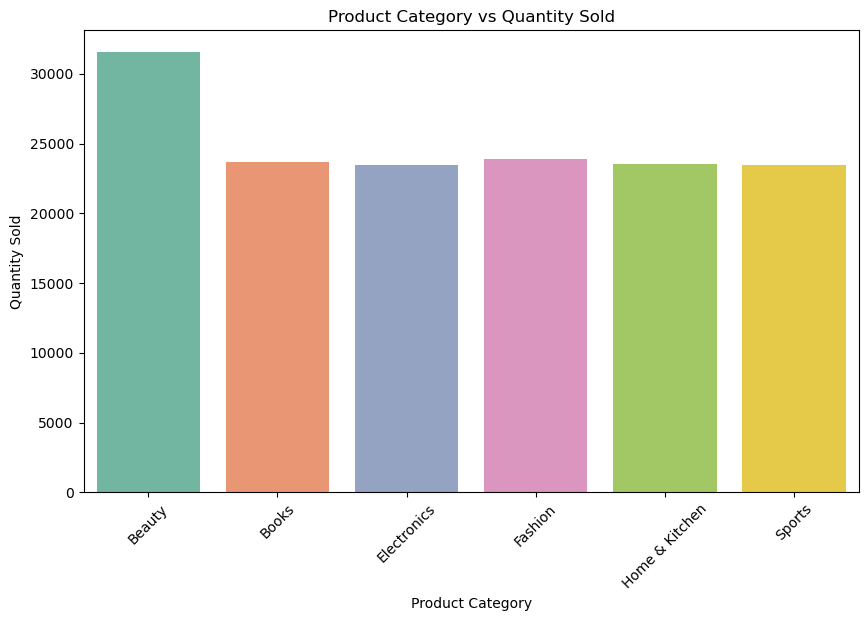

In [87]:
plt.figure(figsize=(10,6))

sns.barplot(x='product_category',
            y='quantity_sold',
            data=category_discount,
            palette='Set2')

plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.title('Product Category vs Quantity Sold')

plt.xticks(rotation=45)
plt.show()

## Rating & Review Analysis

In [88]:
# product_Category wise average Rating
df.groupby('product_category')['rating'].mean().sort_values(ascending=False)

product_category
Books             3.018691
Sports            2.998262
Home & Kitchen    2.997567
Beauty            2.990116
Electronics       2.988853
Fashion           2.986472
Name: rating, dtype: float64

### Products with Highest Number of Reviews:

In [89]:

product_reviews = df.groupby(["product_id","product_category"])["review_count"].sum()

# Sort to find highest reviews
top_products = product_reviews.sort_values(ascending=False)

print("Products with Highest Number of Reviews:")
print(top_products.head(10))


Products with Highest Number of Reviews:
product_id  product_category
3984        Beauty              3238
1375        Beauty              3166
1516        Beauty              2713
3209        Books               2677
2254        Fashion             2669
1006        Beauty              2639
3009        Fashion             2637
4796        Beauty              2613
2785        Fashion             2601
1876        Beauty              2530
Name: review_count, dtype: int64


In [90]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)

In [91]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'year', 'month', 'day', 'day_name',
       'discount_category', 'rating_category'],
      dtype='object')